## Vorbereitung 

**Wie sehen die Daten aus?**

Die Datei ist eine CSV-ähnliche Textdatei vom DWD mit Semikolon als Trennzeichen. Jede Zeile ist eine Terminmessung – der DWD misst dreimal täglich: um 06, 12 und 18 Uhr UTC.

Hier ein Besipiel: 

```csv
STATIONS_ID ; MESS_DATUM  ; QN_4 ; TT_TER ; RF_TER ; eor
5705        ; 2024103106  ;  9   ;   8.8  ;  91.0  ; eor
5705        ; 2024103112  ;  9   ;  13.0  ;  78.0  ; eor
5705        ; 2024103118  ;  9   ;  12.1  ;  83.0  ; eor
```

| Spalte | Bedeutung | Einheit |
|---|---|---|
| `STATIONS_ID` | Stations-ID der DWD-Wetterstation | – (hier immer 05705) |
| `MESS_DATUM` | Datum + Uhrzeit der Messung (Format: YYYYMMDDHH) | – |
| `QN_4` | Qualitätsniveau der Prüfung (9 = vollständig geprüft) | – |
| `TT_TER` | Lufttemperatur (Zielgröße der Analyse) | °C |
| `RF_TER` | Relative Luftfeuchte | % |
| `eor` | End of Record – Dateiformat-Marker, kein Inhalt | – |

Der DWD kodiert fehlende Messwerte mit -999. Das ist kein echter Temperaturwert, sondern ein Platzhalter. (Muss man halt ersetzten/entfernen)

## Datenbereinigung

In [ ]:
import pandas as pd
import numpy as np

# Semikolon als Trennzeichen, Leerzeichen um Spaltennamen entfernen
df = pd.read_csv(
    '/Users/clara/Desktop/uni_dreck/Menden_S26/temperatur_raw_05705_akt/produkt_tu_termin_20241031_20260503_05705.txt',
    sep=';',
    skipinitialspace=True
)
df.columns = df.columns.str.strip()

#vorschau
print(df.head())
print(df.dtypes)
print(df.shape)

   STATIONS_ID  MESS_DATUM  QN_4  TT_TER  RF_TER  eor
0         5705  2024103106     9     8.8    91.0  eor
1         5705  2024103112     9    13.0    78.0  eor
2         5705  2024103118     9    12.1    83.0  eor
3         5705  2024110106     9     8.9    95.0  eor
4         5705  2024110112     9     9.9    89.0  eor
STATIONS_ID      int64
MESS_DATUM       int64
QN_4             int64
TT_TER         float64
RF_TER         float64
eor                str
dtype: object
(1742, 6)


In [2]:
# -999 -> als NaN
df['TT_TER'] = df['TT_TER'].replace(-999.0, np.nan)

# Anazhl Fehlwerte 
print(df['TT_TER'].isna().sum())

13


## Aggregation auf Tagesebene

In [3]:
df['date'] = pd.to_datetime(
    df['MESS_DATUM'].astype(str).str[:8],
    format='%Y%m%d'
)
daily = df.groupby('date')['TT_TER'].mean().rename('temp_mean')
daily = daily.asfreq('D')

print(daily.head(10))
print(f"Fehlende Tage: {daily.isna().sum()}")

date
2024-10-31    11.300000
2024-11-01     9.600000
2024-11-02    10.233333
2024-11-03     8.300000
2024-11-04     3.866667
2024-11-05     3.966667
2024-11-06     5.600000
2024-11-07     5.500000
2024-11-08     5.100000
2024-11-09     5.033333
Freq: D, Name: temp_mean, dtype: float64
Fehlende Tage: 0


In [4]:
daily_clean = daily.interpolate(method='linear')

In [5]:
print(daily_clean.describe())

count    550.000000
mean       9.416106
std        7.515934
min       -5.466667
25%        3.500000
50%        8.870833
75%       14.666667
max       30.966667
Name: temp_mean, dtype: float64


## Stationaritätstests 


In [6]:
from statsmodels.tsa.stattools import adfuller, kpss

# ADF-Test
result_adf = adfuller(daily_clean, regression='ct', autolag='AIC')

print("ADF-Test (Niveau):")
print(f"  Teststatistik : {result_adf[0]:.4f}")
print(f"  p-Wert        : {result_adf[1]:.4f}")
print(f"  Lags genutzt  : {result_adf[2]}")
print("  Kritische Werte:")
for key, val in result_adf[4].items():
    print(f"    {key}: {val:.4f}")

# KPSS-Test
result_kpss = kpss(daily_clean, regression='ct', nlags='auto')

print("\nKPSS-Test (Niveau):")
print(f"  Teststatistik : {result_kpss[0]:.4f}")
print(f"  p-Wert        : {result_kpss[1]:.4f}")

ADF-Test (Niveau):
  Teststatistik : -1.4719
  p-Wert        : 0.8386
  Lags genutzt  : 10
  Kritische Werte:
    1%: -3.9757
    5%: -3.4187
    10%: -3.1319

KPSS-Test (Niveau):
  Teststatistik : 0.5847
  p-Wert        : 0.0100


/var/folders/fl/yk278gfn3kj475yxzp9ypbrh0000gn/T/ipykernel_1566/913877945.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result_kpss = kpss(daily_clean, regression='ct', nlags='auto')


ADF p=0.84 -> unsere H0 wird nicht abgelehnt, dass bedeutet die EInzelwurzel ist vorhanden 
KPSS p < 0.01 -> H0 abgeleht, dass bedeutete das es nicht stationär ist 

In [7]:
d1 = daily_clean.diff().dropna()

#Tests, aber differenzierte Reihe
result_adf_d1 = adfuller(d1, regression='c', autolag='AIC')
print(f"ADF (1. Diff.): p = {result_adf_d1[1]:.4f}")

result_kpss_d1 = kpss(d1, regression='c', nlags='auto')
print(f"KPSS (1. Diff.): p = {result_kpss_d1[1]:.4f}")

ADF (1. Diff.): p = 0.0000
KPSS (1. Diff.): p = 0.1000


/var/folders/fl/yk278gfn3kj475yxzp9ypbrh0000gn/T/ipykernel_1566/2096797797.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result_kpss_d1 = kpss(d1, regression='c', nlags='auto')


Es ist keine zweite Differenzierung nötig, das der Test nach d=1 stätinärität aufzeigt. 

## ACF & PACF

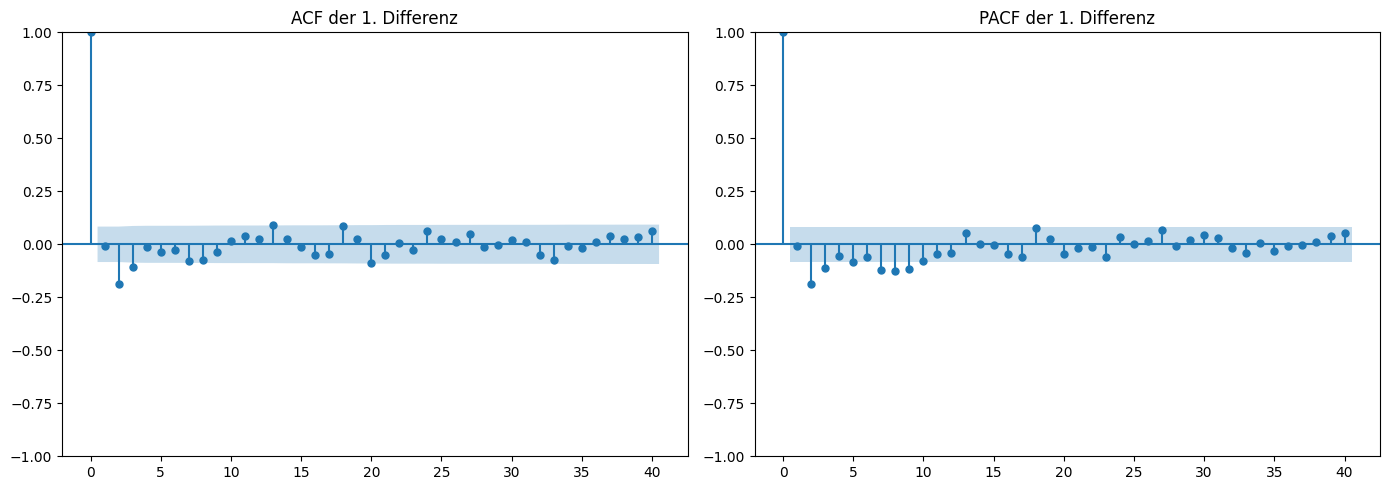

In [9]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(d1,  lags=40, ax=axes[0], alpha=0.05)
axes[0].set_title('ACF der 1. Differenz')

plot_pacf(d1, lags=40, ax=axes[1], method='ywm', alpha=0.05)
axes[1].set_title('PACF der 1. Differenz')

plt.tight_layout()
plt.show()

**Interpretation** 

Was man siehst:
Der blaue Balken bei Lag 0 ist immer 1.0 –> normal, jede Reihe korreliert perfekt mit sich selbst
Das hellblaue Band ist das 95%-Konfidenzintervall – Balken die außerhalb liegen sind statistisch signifikant
Lag 2 ragt in beiden Plots deutlich nach unten heraus – das ist das einzige klar signifikante Signal


ACF:
Nur Lag 2 signifikant, danach alles innerhalb des Bandes
Kein langsames Abklingen → kein Trend mehr vorhanden (das zeigt dass die Differenzierung funktioniert hat)
Ein einzelner signifikanter Lag deutet auf eine MA-Komponente hin → q = 2 als Kandidat 

PACF:
Sieht fast identisch aus wie die ACF
Auch nur Lag 2 signifikant
Deutet auf eine AR-Komponente hin → p = 1 oder 2 als Kandidat

Schlussfolgerung: 
Das Muster ist nicht ganz eindeutig – beide Plots sehen ähnlich aus, was typisch für ein ARMA-Mischmodell ist. Das spricht für kleine Werte von p und q.

## Modelselektion

In [10]:
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

rows = []

for p in range(0, 6):      # AR-Ordnung
    for q in range(0, 6):  # MA-Ordnung
        try:
            m = ARIMA(daily_clean, order=(p, 1, q)).fit()
            rows.append({
                'p': p, 'q': q,
                'AIC': m.aic,
                'BIC': m.bic,
                'LogL': m.llf
            })
        except Exception:
            pass  # Manche Kombinationen konvergieren nicht

rdf = pd.DataFrame(rows)

print("Top 5 nach AIC:")
print(rdf.sort_values('AIC').head(5).to_string(index=False))

print("\nTop 5 nach BIC:")
print(rdf.sort_values('BIC').head(5).to_string(index=False))

Top 5 nach AIC:
 p  q         AIC         BIC         LogL
 2  5 2496.643584 2531.108371 -1240.321792
 3  5 2497.646411 2536.419297 -1239.823205
 4  5 2499.100137 2542.181121 -1239.550068
 1  2 2501.947712 2519.180106 -1246.973856
 5  2 2501.970374 2536.435162 -1242.985187

Top 5 nach BIC:
 p  q         AIC         BIC         LogL
 1  2 2501.947712 2519.180106 -1246.973856
 2  1 2502.217443 2519.449837 -1247.108721
 1  3 2503.839556 2525.380048 -1246.919778
 2  2 2503.856782 2525.397274 -1246.928391
 3  1 2503.878090 2525.418582 -1246.939045


AIC vs. BIC: Beide bestrafen Modellkomplexität (BIC stärker) AIC wählt deshalb oft komplexere Modelle, BIC einfachere. Für Prognose und Interpretierbarkeit ist das sparsamste gut spezifizierte Modell (BIC Kriterium) meist besser. Hier ARIMA(1,1,2).

## Model schätzen

In [11]:
model = ARIMA(daily_clean, order=(1, 1, 2)).fit()
print(model.summary())

                               SARIMAX Results                                
Dep. Variable:              temp_mean   No. Observations:                  550
Model:                 ARIMA(1, 1, 2)   Log Likelihood               -1246.974
Date:                Mon, 11 May 2026   AIC                           2501.948
Time:                        10:38:14   BIC                           2519.180
Sample:                    10-31-2024   HQIC                          2508.682
                         - 05-03-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5689      0.077      7.365      0.000       0.418       0.720
ma.L1         -0.6582      0.080     -8.208      0.000      -0.815      -0.501
ma.L2         -0.2036      0.049     -4.128      0.0

**Fazit:**
1. ACF/PACF hier war nur Lag2 signifikant und alle Werte die danach im Konfidenzband liegen. Das deutet auf ein Model mit kleinem p & q Werten hin. 
2. AIC/BIC hier hat die Gridsuche über die p,q 0-5 ergeben, dass ARIMA (1,1,2) am besten ist (BIC bestraft komplexitt und das Parsimonieprinzip in der Zeitreihe wird bevorzugt). AIC ARIMA (2,1,5) hätte 7 Parameter (BIC nur 3) was bei 550 Datenpuntne zu komplex ist. Die kleinen p&q Werte passen auch zum ACF/PACF Ergebnis. 

## Residualdiagnostik

In [12]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.diagnostic import het_arch

resid = model.resid.dropna()

# Ljung-Box: Test auf Autokorrelation in den Residuen
# H0: keine Autokorrelation bis Lag k
lb = acorr_ljungbox(resid, lags=[10, 20, 30], return_df=True)
print(lb)

# Jarque-Bera: Test auf Normalverteilung
# H0: Residuen sind normalverteilt
jb_stat, jb_p, jb_skew, jb_kurt = jarque_bera(resid)
print(f"JB: Stat={jb_stat:.2f}, p={jb_p:.4f}")
print(f"Schiefe={jb_skew:.3f}, Kurtosis={jb_kurt:.3f}")

# Heteroskedastizitätstest
# H0: keine Heteroskedastizität
arch_stat, arch_p, _, _ = het_arch(resid)
print(f"ARCH-Test: Stat={arch_stat:.4f}, p={arch_p:.4f}")

      lb_stat  lb_pvalue
10   5.593389   0.848191
20  22.293647   0.324791
30  31.429228   0.394532
JB: Stat=28.81, p=0.0000
Schiefe=0.217, Kurtosis=4.034
ARCH-Test: Stat=23.0497, p=0.0106


**Interpretation:**
Ljung-Box p > 0.05 (für alle Lags): Residuen zeigen keine Autokorrelation → Modell ist gut spezifiziert
Jarque-Bera: Kurtosis = 4.03 -> minimal fettere Ränder als Normalverteilung – bei Wetterdaten normal und akzeptabel 
Schiefe = 0.22 -> nahezu symetrisch -> gut 
ARCH-test (konstante Varianz) p>0.05 -> keine Heteroskedastizät -> Model ausreichend

**t-Statistik Fazit:**
ar.L1: t = 7.36 -> hoch signifikant -> gestrige Temperaturveränderung beeinflusst heutige
ma.L1: t = −8.21 -> hoch signifikant-> Fehler von gestern wird korrigiert
ma.L2: t = −4.13 -> signifikant -> Fehler von vorgestern hat noch Einfluss
Alle |t| >> 1.96 -> alle Koeffizienten auf 1% Niveau signifikant -> kein Parameter überflüssig



## Prognose

In [13]:
forecast = model.get_forecast(steps=10)

# Punktprognose
fc_mean = forecast.predicted_mean

# Konfidenzintervall (alpha=0.05 -> 95%-Kontingenzintervall)
fc_ci = forecast.conf_int(alpha=0.05)

result = pd.concat([fc_mean.rename('Prognose'), fc_ci], axis=1)
result.columns = ['Prognose', 'KI_unten', 'KI_oben']
print(result.round(2))

            Prognose  KI_unten  KI_oben
2026-05-04     15.66     11.07    20.26
2026-05-05     14.81      8.59    21.02
2026-05-06     14.32      7.41    21.23
2026-05-07     14.05      6.75    21.34
2026-05-08     13.89      6.33    21.45
2026-05-09     13.80      6.04    21.56
2026-05-10     13.75      5.82    21.68
2026-05-11     13.72      5.64    21.80
2026-05-12     13.70      5.48    21.93
2026-05-13     13.69      5.33    22.05
